In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [5]:
client_df = pd.read_excel("data/Client data.xlsx")
aces_df = pd.read_excel("data/ACEs and Victimization.xlsx", sheet_name="ACEs")
victim_df = pd.read_excel("data/ACEs and Victimization.xlsx", sheet_name="Victimization")

print("Client data shape:", client_df.shape)
print("ACEs shape:", aces_df.shape)
print("Victimization shape:", victim_df.shape)

Client data shape: (444, 113)
ACEs shape: (373, 14)
Victimization shape: (386, 20)


In [6]:
client_df.head()

,ClientID,ACES,Victimization,Education level?,RelationToHoH,FamilySize,FamilyType,Birthdate,DOBDataQuality,AgeAtLastEntry,Race,Sex,ProgramName,EnrollmentBegin,EnrollmentEnd,VeteranStatus,EntryIncomeDataQuality,EntryTotalIncome,EntryEarnedIncome,LatestIncomeDataQuality,LatestTotalIncome,LatestEarnedIncome,EntryEarned,Earned,EntryUnemployment,Unemployment,EntrySSI,SSI,EntrySSDI,SSDI,EntryVADisabilityService,VADisabilityService,EntryVADisabilityNonService,VADisabilityNonService,EntryPrivateDisability,PrivateDisability,EntryWorkersComp,WorkersComp,EntryTANF,TANF,EntryGA,GA,EntrySocSecRetirement,SocSecRetirement,EntryPension,Pension,EntryChildSupport,ChildSupport,EntryAlimony,Alimony,EntryOtherIncomeSource,OtherIncomeSource,EntryNonCashBenefit,LatestNonCashBenefit,EntrySNAP,SNAP,EntryWIC,WIC,EntryTANFChildCare,TANFChildCare,EntryTANFTransportation,TANFTransportation,EntryOtherTANF,OtherTANF,EntryOtherNonCash,OtherNonCash,HealthInsuranceEntry,EntryNumSourceHealthInsurance,HealthInsurance,NumSourceHealthInsurance,EntryMedicaid,Medicaid,EntryMedicare,Medicare,EntrySCHIP,SCHIP,EntryVAMedicalServices,VAMedicalServices,EntryCOBRA,COBRA,EntryEmployerProvided,EmployerProvided,EntryPrivatePay,PrivatePay,EntryStateHealthIns,StateHealthIns,EntryIndianHealthServices,EntryIndianHealthServices2,EntryOtherHealthIns,OtherHealthIns,DisablingCondition,NumConditionsEntry,NumConditions,NumConditionsLatest,PhysicalDistability_Entry,PhysicalDisablity_Latest,DevelopmentalDisabled_Entry,DevelopmentalDisabled_Latest,ChronicIllness_Entry,ChronicIllness_Lates,MentalIllness_Entry,MentalIllness_Latest,SubstanceAbuse_Entry,SubstanceAbuse_Latest,HIVStatus_Entry,HIVAids_Latest,DomesticViolence_Entry,DVWhen_Entry,FleeingDV_Entry,LeaverStayer,StayLength,ExitDestination_Latest,DateStartedOnStreets
0,379464,Yes,Yes,11th grade,Self,8,With Children and Adults,1994-09-15,Full DOB reported,29,White,Female,SAMM CoC Housing First PSH,2023-10-18,1999-12-31,No,No,0.0,0.0,No,0.00,0.00,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,Yes,0,Yes,1,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,1,1,1,No,No,No,No,No,No,Yes,Yes,No,No,No,No,Yes,One year ago or more,No,Stayer,847,NaN,2022-08-22
1,387431,Yes,Yes,High school diploma,Self,2,With Children and Adults,1985-02-21,Full DOB reported,39,"Hispanic/Latina/o, White",Male,SAMM HUD RRH,2024-07-09,2025-07-31,No,Yes,1500.0,1500.0,Yes,1500.00,1500.00,Yes,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,Yes,1,Yes,0,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,1,1,1,No,No,No,No,Yes,Yes,No,No,No,No,No,No,No,NaN,NaN,Leaver,387,"Rental by client, no ongoing housing subsidy",2024-03-12
2,355696,Yes,Yes,High school diploma,Self,8,With Children and Adults,1991-09-14,Full DOB reported,32,"Black, African American or African",Client prefers not to answer,SAMM ESG COSA RRH,2024-04-17,2025-10-24,Yes,Yes,3600.0,3600.0,Yes,8000.00,7500.00,Yes,Yes,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No,No,No,No,No,No,No,No,Yes,2,Yes,2,No,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,No,No,No,No,No,No,No,No,No,0,0,0,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,NaN,Leaver,555,"Owned by client, no ongoing housing subsidy",2023-03-03
3,429976,Yes,Yes,GED or high school equivalency,Head of household’s spouse or partner,4,With Children and Adults,1990-11-07,Full DOB reported,33,White,Male,SAMM CoC DV Bonus Joint TH,2024-02-21,2025-05-29,No,No,0.0,0.0,No,0.00,0.00,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,No,No,No,No,0,No,0,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,0,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,NaN,Leaver,463,"Rental by client, with ongoing housing subsidy",2024-01-01
4,334435,Yes,Yes,High

In [7]:
aces_df.head()

,Client ID (HMIS or other if available),Program Name,"While you were growing up, during your first 18 years of life:\nDid you feel that you didn’t have enough to eat, had to wear dirty clothes, or had no one to protect or take care of you?\n","While you were growing up, during your first 18 years of life:\nDid you lose a parent through divorce, abandonment, death, or other reason?","While you were growing up, during your first 18 years of life:\nDid you live with anyone who was depressed, mentally ill, or attempted suicide?\n","While you were growing up, during your first 18 years of life:\nDid you live with anyone who had a problem with drinking or using drugs, including prescription drugs?\n","While you were growing up, during your first 18 years of life:\nDid your parents or adults in your home ever hit, punch, beat, or threaten to harm each other?\n","While you were growing up, during your first 18 years of life:\nDid you live with anyone who went to jail or prison?\n","While you were growing up, during your first 18 years of life:\nDid a parent or adult in your home ever swear at you, insult you, or put you down?\n","While you were growing up, during your first 18 years of life:\nDid a parent or adult in your home ever hit, beat, kick, or physically hurt you in any way\n","While you were growing up, during your first 18 years of life:\nDid you feel that no one in your family loved you or thought you were special?\n","While you were growing up, during your first 18 years of life:\nDid you experience unwanted sexual contact (such as fondling or oral/anal/vaginal intercourse/penetration)?",Total,Do you believe that these experiences have affected your health?stion
0,342019,Transitional Living and Learning Center (TLLC),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10,A Lot.;
1,373020,Transitional Living and Learning Center (TLLC),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10,A Lot.;
2,166808,DV Transitional to Rapid Rehosing,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10,Not at all.;
3,412594,Transitional Living and Learning Center (TLLC),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10,A Lot.;
4,396427,DV Transitional to Rapid Rehosing,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10,A Lot.;


In [8]:
victim_df.head()

,Client ID (HMIS or other if available),Program Name,Are you a citizen of the United States?,"If not, a U.S. Citizen, please list details below. Are you seeking asylum? Do you have an expired VISA? What are the circumstances? Do you need assistance with this process?",Gender Identity,Race/Ethnicity,Special Classification: Do any of the following apply to you?,Victimization: Select any of the below traumas you personally experienced.,Was more than one Type of Victimization Selected?\n\n,"If you answered YES to domestic/family violence, sexual assault, human trafficking or stalking, were any of the incidents within the last 2 years and in the home you lived in?\n\n",Did you report any incidents to law enforcement and have you been cooperative with pursuing charges?,Family Victimization: Has any of your immediate family members (being served by SAMM) experienced the traumas?,"My most recent significant, romantic relationship (Check one):\n",Physically hurt you,Insult or talk down to you,Threaten you with harm,Scream or curse at you,Force you to do sexual acts that you are not comfortable with,In my current or most recent relationship:,"If violence had occurred in the most recent relationship, the last incident of abuse occurred:\n"
0,220036,Permanent Supportive Housing (PSH),"Yes, born in the United States.",NaN,Female,Black/African American;,Disabilities: Cognitive/Physical/Mental;,Adult Physical Assault (includes aggravated an...,Yes,No,Yes,"Yes (If yes, complete a separate family member...",Was More than a Year Ago;,Frequently,Often,Often,Often,Often,I have experienced domestic violence I am NOT ...,Over a Year Ago;
1,172235,Permanent Supportive Housing (PSH),"Yes, born in the United States.",NaN,Male,White Non-Latino/Caucasian;,Homeless;Disabilities: Cognitive/Physical/Mental;,Adult Physical Assault (includes aggravated an...,Yes,No,Na,No;,Was More than a Year Ago;,Never,Sometimes,Never,Sometimes,Never,I have NOT experienced domestic violence.;,Not applicable. No violence had occurred.;
2,383224,Emergency Shelter,NaN,NaN,Female,Hispanic or Latino ;,Homeless;LGBTQ;Disabilities: Cognitive/Physica...,"Bullying (Verbal, Cyber, or Physical);Domestic...",Yes,NaN,NaN,"Yes (If yes, complete a separate family member...",Was More than a Year Ago;,Sometimes,Sometimes,Frequently,Sometimes,Rarely,NaN,NaN
3,399986,Emergency Shelter,NaN,NaN,Not on form,Hispanic or Latino ;,Homeless;Disabilities: Cognitive/Physical/Mental;,Not applicable. I have never experienced the ...,No,NaN,NaN,NaN,"I have never had a significant, romantic relat...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,250438,Emergency Shelter,NaN,NaN,Not asked on paper form,White Non-Latino/Caucasian;,Homeless;,Not applicable. I have never experienced the ...,No,NaN,NaN,NaN,Was More than a Year Ago;,Never,Never,Never,Never,Never,I have NOT experienced domestic violence.;,NaN


In [9]:
print(client_df.columns)
print(aces_df.columns)
print(victim_df.columns)

Index(['ClientID', 'ACES', 'Victimization', 'Education level?',
       'RelationToHoH', 'FamilySize', 'FamilyType', 'Birthdate',
       'DOBDataQuality', 'AgeAtLastEntry',
       ...
       'SubstanceAbuse_Latest', 'HIVStatus_Entry', 'HIVAids_Latest',
       'DomesticViolence_Entry', 'DVWhen_Entry', 'FleeingDV_Entry',
       'LeaverStayer', 'StayLength', 'ExitDestination_Latest',
       'DateStartedOnStreets'],
      dtype='object', length=113)
Index(['Client ID (HMIS or other if available) ', 'Program Name',
       'While you were growing up, during your first 18 years of life:\nDid you feel that you didn’t have enough to eat, had to wear dirty clothes, or had no one to protect or take care of you?\n',
       'While you were growing up, during your first 18 years of life:\nDid you lose a parent through divorce, abandonment, death, or   other reason?',
       'While you were growing up, during your first 18 years of life:\nDid you live with anyone who was depressed, mentally ill, or at

In [10]:
# Rename important ACE columns
aces_df = aces_df.rename(columns={
    aces_df.columns[0]: "ClientID",
    "Total": "ACES_Total"
})

# Keep only what we need
aces_df = aces_df[["ClientID", "ACES_Total"]]

aces_df.head()

,ClientID,ACES_Total
0,342019,10
1,373020,10
2,166808,10
3,412594,10
4,396427,10


In [31]:
victim_df.columns = victim_df.columns.str.strip()

victim_df = victim_df.rename(columns={
    "Race/Ethnicity": "Victim_Race",
    "Victimization:\xa0 Select any of the below traumas you personally experienced.": "Victim_Trauma"
})

victim_subset = victim_df[
    ["ClientID", "Victim_Gender", "Victim_Race", "Victim_Trauma", "Multiple_Victimization"]
].copy()

victim_subset.head()

,ClientID,Victim_Gender,Victim_Race,Victim_Trauma,Multiple_Victimization
0,220036,Female,Black/African American;,Adult Physical Assault (includes aggravated an...,Yes
1,172235,Male,White Non-Latino/Caucasian;,Adult Physical Assault (includes aggravated an...,Yes
2,383224,Female,Hispanic or Latino ;,"Bullying (Verbal, Cyber, or Physical);Domestic...",Yes
3,399986,Not on form,Hispanic or Latino ;,Not applicable. I have never experienced the ...,No
4,250438,Not asked on paper form,White Non-Latino/Caucasian;,Not applicable. I have never experienced the ...,No


In [12]:
victim_df.columns = victim_df.columns.str.strip()
for col in victim_df.columns:
    print(repr(col))

'ClientID'
'Program Name'
'Are you a citizen of the United States?'
'If not, a U.S. Citizen, please list details below.\xa0 Are you seeking asylum?\xa0 Do you have an expired VISA?\xa0 What are the circumstances?\xa0 Do you need assistance with this process?'
'Victim_Gender'
'Race/Ethnicity'
'Special Classification:\xa0 Do any of the following apply to you?'
'Victimization:\xa0 Select any of the below traumas you personally experienced.'
'Multiple_Victimization'
'If you answered YES to domestic/family violence, sexual assault, human trafficking or stalking, were any of the incidents within the last 2 years and in the home you lived in?'
'Did you report any incidents to law enforcement and have you been cooperative with pursuing charges?'
'Family Victimization:\xa0 Has any of your immediate family members (being served by SAMM) experienced the traumas?'
'My\xa0most recent significant, romantic relationship (Check one):'
'Physically hurt you'
'Insult or talk down to you'
'Threaten you wi

In [13]:
victim_df = victim_df.rename(columns={
    "Race/Ethnicity": "Victim_Race",
    "Victimization:\xa0 Select any of the below traumas you personally experienced.": "Victim_Trauma"
})

victim_subset = victim_df[
    ["ClientID", "Victim_Gender", "Victim_Race", "Victim_Trauma", "Multiple_Victimization"]
].copy()

victim_subset.head()

,ClientID,Victim_Gender,Victim_Race,Victim_Trauma,Multiple_Victimization
0,220036,Female,Black/African American;,Adult Physical Assault (includes aggravated an...,Yes
1,172235,Male,White Non-Latino/Caucasian;,Adult Physical Assault (includes aggravated an...,Yes
2,383224,Female,Hispanic or Latino ;,"Bullying (Verbal, Cyber, or Physical);Domestic...",Yes
3,399986,Not on form,Hispanic or Latino ;,Not applicable. I have never experienced the ...,No
4,250438,Not asked on paper form,White Non-Latino/Caucasian;,Not applicable. I have never experienced the ...,No


In [14]:
# Convert numeric columns in client data
client_df["StayLength"] = pd.to_numeric(client_df["StayLength"], errors="coerce")
client_df["AgeAtLastEntry"] = pd.to_numeric(client_df["AgeAtLastEntry"], errors="coerce")
client_df["EntryTotalIncome"] = pd.to_numeric(client_df["EntryTotalIncome"], errors="coerce")
client_df["LatestTotalIncome"] = pd.to_numeric(client_df["LatestTotalIncome"], errors="coerce")

# Remove impossible negative stay lengths
client_df.loc[client_df["StayLength"] < 0, "StayLength"] = np.nan

# Merge all datasets
df = client_df.merge(aces_df, on="ClientID", how="left")
df = df.merge(victim_subset, on="ClientID", how="left")

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (449, 118)


,ClientID,ACES,Victimization,Education level?,RelationToHoH,FamilySize,FamilyType,Birthdate,DOBDataQuality,AgeAtLastEntry,Race,Sex,ProgramName,EnrollmentBegin,EnrollmentEnd,VeteranStatus,EntryIncomeDataQuality,EntryTotalIncome,EntryEarnedIncome,LatestIncomeDataQuality,LatestTotalIncome,LatestEarnedIncome,EntryEarned,Earned,EntryUnemployment,Unemployment,EntrySSI,SSI,EntrySSDI,SSDI,EntryVADisabilityService,VADisabilityService,EntryVADisabilityNonService,VADisabilityNonService,EntryPrivateDisability,PrivateDisability,EntryWorkersComp,WorkersComp,EntryTANF,TANF,EntryGA,GA,EntrySocSecRetirement,SocSecRetirement,EntryPension,Pension,EntryChildSupport,ChildSupport,EntryAlimony,Alimony,EntryOtherIncomeSource,OtherIncomeSource,EntryNonCashBenefit,LatestNonCashBenefit,EntrySNAP,SNAP,EntryWIC,WIC,EntryTANFChildCare,TANFChildCare,EntryTANFTransportation,TANFTransportation,EntryOtherTANF,OtherTANF,EntryOtherNonCash,OtherNonCash,HealthInsuranceEntry,EntryNumSourceHealthInsurance,HealthInsurance,NumSourceHealthInsurance,EntryMedicaid,Medicaid,EntryMedicare,Medicare,EntrySCHIP,SCHIP,EntryVAMedicalServices,VAMedicalServices,EntryCOBRA,COBRA,EntryEmployerProvided,EmployerProvided,EntryPrivatePay,PrivatePay,EntryStateHealthIns,StateHealthIns,EntryIndianHealthServices,EntryIndianHealthServices2,EntryOtherHealthIns,OtherHealthIns,DisablingCondition,NumConditionsEntry,NumConditions,NumConditionsLatest,PhysicalDistability_Entry,PhysicalDisablity_Latest,DevelopmentalDisabled_Entry,DevelopmentalDisabled_Latest,ChronicIllness_Entry,ChronicIllness_Lates,MentalIllness_Entry,MentalIllness_Latest,SubstanceAbuse_Entry,SubstanceAbuse_Latest,HIVStatus_Entry,HIVAids_Latest,DomesticViolence_Entry,DVWhen_Entry,FleeingDV_Entry,LeaverStayer,StayLength,ExitDestination_Latest,DateStartedOnStreets,ACES_Total,Victim_Gender,Victim_Race,Victim_Trauma,Multiple_Victimization
0,379464,Yes,Yes,11th grade,Self,8,With Children and Adults,1994-09-15,Full DOB reported,29,White,Female,SAMM CoC Housing First PSH,2023-10-18,1999-12-31,No,No,0.0,0.0,No,0.00,0.00,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,Yes,0,Yes,1,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,1,1,1,No,No,No,No,No,No,Yes,Yes,No,No,No,No,Yes,One year ago or more,No,Stayer,847.0,NaN,2022-08-22,10.0,Female,White Non-Latino/Caucasian;,Not applicable. I have never experienced the ...,NaN
1,387431,Yes,Yes,High school diploma,Self,2,With Children and Adults,1985-02-21,Full DOB reported,39,"Hispanic/Latina/o, White",Male,SAMM HUD RRH,2024-07-09,2025-07-31,No,Yes,1500.0,1500.0,Yes,1500.00,1500.00,Yes,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,Yes,1,Yes,0,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,1,1,1,No,No,No,No,Yes,Yes,No,No,No,No,No,No,No,NaN,NaN,Leaver,387.0,"Rental by client, no ongoing housing subsidy",2024-03-12,10.0,Male,Hispanic or Latino ;,Not applicable. I have never experienced the ...,NaN
2,355696,Yes,Yes,High school diploma,Self,8,With Children and Adults,1991-09-14,Full DOB reported,32,"Black, African American or African",Client prefers not to answer,SAMM ESG COSA RRH,2024-04-17,2025-10-24,Yes,Yes,3600.0,3600.0,Yes,8000.00,7500.00,Yes,Yes,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No,No,No,No,No,No,No,No,Yes,2,Yes,2,No,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,No,No,No,No,No,No,No,No,No,0,0,0,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,NaN,Leaver,555.0,"Owned by client, no ongoing housing subsidy",2023-03-03,2.0,Male,Black/African American;,Not applicable. I have never experienced the ...,No
3,429976,Yes,Yes,GED or high school equivalency,Head of household’s spouse or partner,4,With Children and Adults,1990-11-07,Full DOB reported,33,White,Male,SAMM CoC DV Bonus Joint TH,2024-02-21,2025-05-29,No,No,0.0,0.0,No,0.00,0.00,No,No,No,No,

In [15]:
print(df.shape)
print(df[["StayLength", "ACES_Total", "AgeAtLastEntry", "EntryTotalIncome", "LatestTotalIncome"]].isna().sum())

(449, 118)
StayLength             1
ACES_Total            73
AgeAtLastEntry         0
EntryTotalIncome       2
LatestTotalIncome    118
dtype: int64


In [16]:
df[["StayLength", "ACES_Total", "AgeAtLastEntry", "EntryTotalIncome", "LatestTotalIncome"]].describe()

,StayLength,ACES_Total,AgeAtLastEntry,EntryTotalIncome,LatestTotalIncome
count,448.000000,376.000000,449.000000,447.000000,331.000000
mean,722.808036,4.808511,40.429844,540.703132,751.384622
std,1059.882657,3.349114,14.048548,857.493211,1160.654968
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,162.000000,2.000000,30.000000,0.000000,0.000000
50%,356.500000,5.000000,39.000000,0.000000,76.000000
75%,715.250000,8.000000,50.000000,940.000000,995.000000
max,6432.000000,10.000000,86.000000,9000.000000,9000.000000


In [17]:
# Income change
df["IncomeChange"] = df["LatestTotalIncome"] - df["EntryTotalIncome"]

# Simplify education
def simplify_education(value):
    if pd.isna(value):
        return "Unknown"
    value = str(value).lower()
    if "bachelor" in value or "master" in value or "college" in value:
        return "College+"
    elif "high school" in value or "ged" in value:
        return "High School/GED"
    elif "grade" in value:
        return "Below High School"
    else:
        return "Other"

df["EducationGroup"] = df["Education level?"].apply(simplify_education)

# Clean race and sex
df["RaceGroup"] = df["Race"].fillna("Unknown").astype(str)
df["Sex"] = df["Sex"].fillna("Unknown").astype(str)

# Convert yes/no variables if present
yes_no_map = {"Yes": 1, "No": 0}

for col in ["DisablingCondition", "VeteranStatus", "DomesticViolence_Entry"]:
    if col in df.columns:
        df[col] = df[col].map(yes_no_map)

df[["IncomeChange", "EducationGroup", "RaceGroup", "Sex"]].head()

,IncomeChange,EducationGroup,RaceGroup,Sex
0,0.00,Below High School,White,Female
1,0.00,High School/GED,"Hispanic/Latina/o, White",Male
2,4400.00,High School/GED,"Black, African American or African",Client prefers not to answer
3,0.00,High School/GED,White,Male
4,2823.17,High School/GED,"Hispanic/Latina/o, White",Female


In [26]:
import os
os.makedirs("visuals", exist_ok=True)

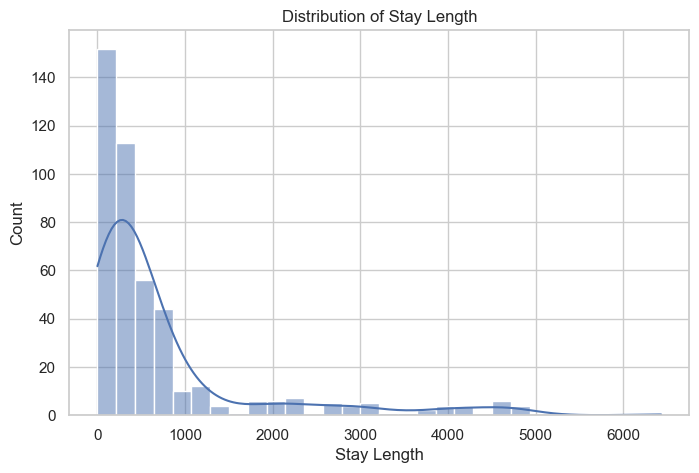

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["StayLength"].dropna(), bins=30, kde=True)
plt.title("Distribution of Stay Length")
plt.xlabel("Stay Length")
plt.ylabel("Count")
plt.savefig("visuals/stay_length_distribution.png")
plt.show()

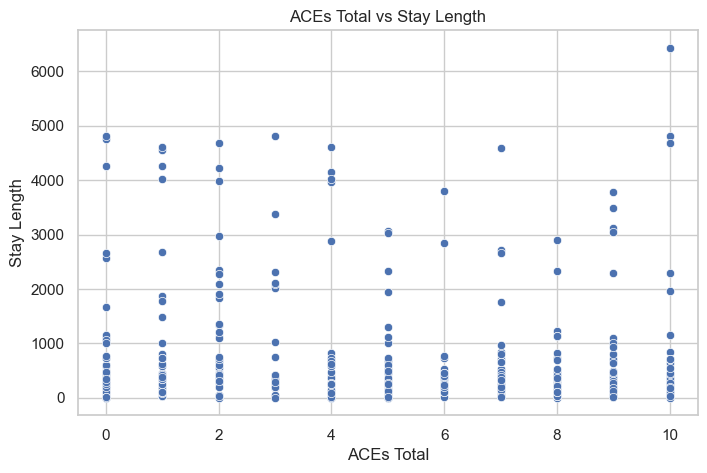

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="ACES_Total", y="StayLength")
plt.title("ACEs Total vs Stay Length")
plt.xlabel("ACEs Total")
plt.ylabel("Stay Length")
plt.savefig("visuals/aces_vs_staylength.png")
plt.show()

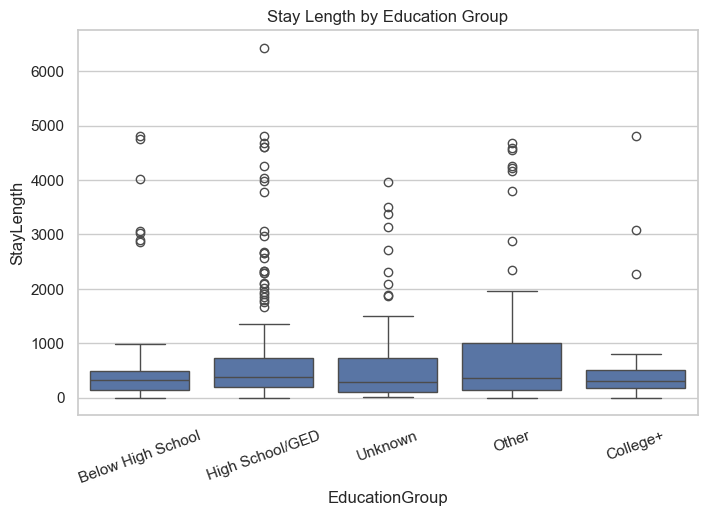

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="EducationGroup", y="StayLength")
plt.title("Stay Length by Education Group")
plt.xticks(rotation=20)
plt.savefig("visuals/education_vs_staylength.png")
plt.show()

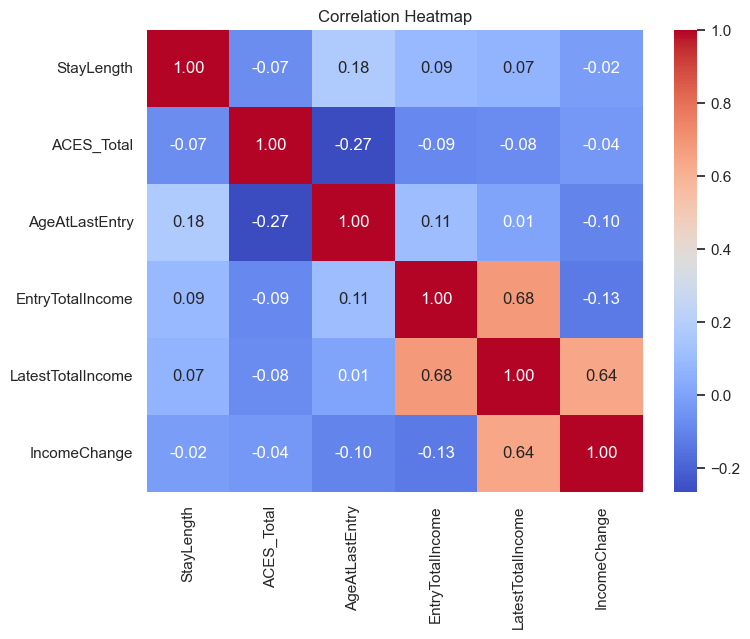

In [30]:
numeric_view = df[["StayLength", "ACES_Total", "AgeAtLastEntry", "EntryTotalIncome", "LatestTotalIncome", "IncomeChange"]]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_view.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("visuals/correlation_heatmap.png")
plt.show()

In [22]:
model_df = df[[
    "StayLength",
    "ACES_Total",
    "AgeAtLastEntry",
    "EntryTotalIncome",
    "IncomeChange",
    "Sex",
    "RaceGroup",
    "EducationGroup",
    "DisablingCondition",
    "DomesticViolence_Entry",
    "VeteranStatus"
]].copy()

model_df = model_df.dropna(subset=["StayLength"])

X = model_df.drop(columns="StayLength")
y = model_df["StayLength"]

numeric_features = [
    "ACES_Total",
    "AgeAtLastEntry",
    "EntryTotalIncome",
    "IncomeChange",
    "DisablingCondition",
    "DomesticViolence_Entry",
    "VeteranStatus"
]

categorical_features = [
    "Sex",
    "RaceGroup",
    "EducationGroup"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2:", round(r2, 3))

MAE: 758.85
RMSE: 1158.75
R^2: -0.021


In [23]:
# Create ACE risk category
df["ACE_Risk"] = pd.cut(
    df["ACES_Total"],
    bins=[-1, 2, 5, 10],
    labels=["Low", "Medium", "High"]
)

# Create age groups
df["AgeGroup"] = pd.cut(
    df["AgeAtLastEntry"],
    bins=[0, 25, 40, 60, 100],
    labels=["Youth", "Young Adult", "Adult", "Senior"]
)

# Income category
df["IncomeLevel"] = pd.cut(
    df["EntryTotalIncome"],
    bins=[-1, 500, 1500, 5000, 10000],
    labels=["Very Low", "Low", "Moderate", "High"]
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Random Forest Results:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2:", round(r2, 3))

Random Forest Results:
MAE: 661.19
RMSE: 1081.44
R^2: 0.11


In [ ]:
## Final Insights

This analysis explored how demographic, economic, and trauma-related factors influence housing stability outcomes.

While predictive models were able to capture some patterns, results showed that housing stability is only partially explained by the available variables. Random Forest models outperformed linear regression, suggesting non-linear relationships between features and outcomes.

Key drivers of stability appear to include income-related variables and broader contextual factors, while trauma indicators such as ACEs contribute but are not dominant predictors.

These findings highlight the importance of combining data-driven insights with case-level expertise when designing interventions.

## Recommendations

- Use predictive analytics to support, not replace, decision-making
- Target interventions using multiple risk indicators
- Improve data collection on program participation and support services
- Focus on early intervention for high-risk populations